In [34]:
from IPython.display import HTML

display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700;800&display=swap');

*{box-sizing:border-box;}
.hs2{font-family:'Inter','DejaVu Sans',sans-serif;}

/* HERO CONTAINER */
.hero {
    position:relative;
    overflow:hidden;
    border-radius:22px;
    padding:60px;
    background:linear-gradient(135deg,#6366F1 0%,#3B82F6 40%,#06B6D4 100%);
    color:white;
    margin:12px 0 28px 0;

    /* GLASS + GLOW */
    box-shadow:
        0 10px 40px rgba(0,0,0,0.25),
        0 0 60px rgba(99,102,241,0.35),
        inset 0 0 40px rgba(255,255,255,0.08);

    backdrop-filter: blur(12px);

    animation: heroEnter 1s ease forwards;
    opacity:0;
}

/* ENTRY */
@keyframes heroEnter {
    from {opacity:0; transform:translateY(50px) scale(0.98);}
    to {opacity:1; transform:translateY(0) scale(1);}
}

/* GLOW OVERLAY */
.hero::before {
    content:'';
    position:absolute;
    inset:0;
    background: radial-gradient(circle at 20% 30%, rgba(255,255,255,0.15), transparent 40%),
                radial-gradient(circle at 80% 70%, rgba(255,255,255,0.12), transparent 40%);
    pointer-events:none;
}

/* FLOATING ORBS */
.orb {
    position:absolute;
    border-radius:50%;
    filter: blur(20px);
    opacity:0.6;
    animation: float 10s ease-in-out infinite;
}

.orb1 {
    width:260px; height:260px;
    background:#7c83ff;
    top:-80px; right:-60px;
}

.orb2 {
    width:180px; height:180px;
    background:#22d3ee;
    bottom:-60px; right:40px;
    animation-delay:2s;
}

@keyframes float {
    0% {transform:translateY(0);}
    50% {transform:translateY(-25px);}
    100% {transform:translateY(0);}
}

/* TITLE GLOW */
.title {
    font-size:64px;
    font-weight:800;
    letter-spacing:-2px;
    text-shadow: 0 0 20px rgba(255,255,255,0.35);
}

/* SUBTEXT */
.subtitle {
    font-size:18px;
    font-weight:300;
    opacity:0.9;
    max-width:520px;
    line-height:1.6;
}

/* TAGS */
.tag {
    background:rgba(255,255,255,0.15);
    padding:8px 18px;
    border-radius:30px;
    font-size:13px;
    font-weight:500;
    backdrop-filter: blur(8px);

    transition: all 0.3s ease;
}

.tag:hover {
    transform:translateY(-6px) scale(1.08);
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
    background:rgba(255,255,255,0.25);
}

/* MICRO GLOW ON HOVER */
.hero:hover {
    box-shadow:
        0 20px 60px rgba(0,0,0,0.35),
        0 0 90px rgba(99,102,241,0.5),
        inset 0 0 60px rgba(255,255,255,0.1);
}
</style>

<div class="hs2 hero">

    <div class="orb orb1"></div>
    <div class="orb orb2"></div>

    <div style="font-size:11px;font-weight:700;letter-spacing:3px;opacity:0.75;margin-bottom:14px;">
        NFHS-5 · INDIA · 2019–21
    </div>

    <div class="title">HEALTHSCAPE</div>

    <div class="subtitle" style="margin:16px 0 34px 0;">
        Understanding health inequality in India — where it lives, how deep it runs, and what drives it.
    </div>

    <div style="display:flex;gap:12px;flex-wrap:wrap;">
        <div class="tag">36 States & UTs</div>
        <div class="tag">6 Core Indicators</div>
        <div class="tag">Rural vs Urban</div>
        <div class="tag">Varchasvee Yaduvanshee</div>
    </div>

</div>
"""))

In [29]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   HEALTHSCAPE  ·  Setup & Design System                          ║
# ╚══════════════════════════════════════════════════════════════════╝
import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import HTML, display

os.makedirs('images', exist_ok=True)
os.makedirs('data',   exist_ok=True)

# ── Design tokens ──────────────────────────────────────────────────
BG_MAIN      = '#F7F9FC'
BG_CARD      = '#FFFFFF'
TEXT_PRIMARY = '#111827'
TEXT_MUTED   = '#6B7280'
PRIMARY      = '#6366F1'
SECONDARY    = '#06B6D4'
SUCCESS      = '#10B981'
DANGER       = '#EF4444'
WARN         = '#F59E0B'

plt.rcParams.update({
    'figure.facecolor':'#F7F9FC','axes.facecolor':'#FFFFFF',
    'axes.edgecolor':'#E5E7EB','axes.labelcolor':'#111827',
    'text.color':'#111827','xtick.color':'#6B7280','ytick.color':'#6B7280',
    'axes.titleweight':'bold','axes.titlesize':13,'axes.labelsize':10.5,
    'font.size':10,'axes.grid':True,'grid.alpha':0.28,'grid.color':'#E5E7EB',
    'axes.spines.top':False,'axes.spines.right':False,'font.family':'DejaVu Sans',
})
print('\u2713  HEALTHSCAPE v2 ready')

✓  HEALTHSCAPE v2 ready


In [30]:
# ── DATA ─────────────────────────────────────────────────────────────
# Replace with: df = pd.read_csv('data/nfhs5.csv')
np.random.seed(7)
STATES = [
    'Andhra Pradesh','Arunachal Pradesh','Assam','Bihar','Chhattisgarh',
    'Goa','Gujarat','Haryana','Himachal Pradesh','Jharkhand','Karnataka',
    'Kerala','Madhya Pradesh','Maharashtra','Manipur','Meghalaya','Mizoram',
    'Nagaland','Odisha','Punjab','Rajasthan','Sikkim','Tamil Nadu','Telangana',
    'Tripura','Uttar Pradesh','Uttarakhand','West Bengal','Delhi',
    'Jammu & Kashmir','Puducherry','Chandigarh','Ladakh',
    'Andaman & Nicobar','Dadra & NH','Lakshadweep'
]
COLS   = ['female_literacy','sanitation','institutional_births',
          'infant_mortality','stunting','underweight']
LABELS = {'female_literacy':'Female Literacy','sanitation':'Sanitation',
          'institutional_births':'Instit. Births','infant_mortality':'Infant Mortality',
          'stunting':'Stunting','underweight':'Underweight'}

rows = []
for st in STATES:
    base = float(np.clip(np.random.beta(2.5,2)*0.55+0.25, 0.15, 0.97))
    for area, boost in [('Urban',+0.13),('Rural',-0.11),('Total',0)]:
        b = float(np.clip(base+boost, 0.15, 0.97))
        rows.append(dict(
            State=st, Area=area,
            female_literacy      = float(np.clip(b*100+np.random.normal(0,3),  28, 99)),
            sanitation           = float(np.clip(b*100+np.random.normal(0,4),  18,100)),
            institutional_births = float(np.clip(b*100+np.random.normal(2,3),  35,100)),
            infant_mortality     = float(np.clip(65-b*56+np.random.normal(0,3),  3, 72)),
            stunting             = float(np.clip(55-b*42+np.random.normal(0,3),  9, 58)),
            underweight          = float(np.clip(48-b*36+np.random.normal(0,3),  7, 52)),
        ))

df       = pd.DataFrame(rows)
df_total = df[df.Area=='Total'].set_index('State').drop(columns='Area')
df_urban = df[df.Area=='Urban'].set_index('State').drop(columns='Area')
df_rural = df[df.Area=='Rural'].set_index('State').drop(columns='Area')

display(HTML(f"""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#FFFFFF;border-radius:12px;
            padding:18px 24px;border:1px solid #E5E7EB;margin:8px 0;display:flex;gap:40px;flex-wrap:wrap;'>
  <div><div style='font-size:26px;font-weight:800;color:#6366F1;'>{len(STATES)}</div><div style='font-size:12px;color:#6B7280;'>States / UTs</div></div>
  <div><div style='font-size:26px;font-weight:800;color:#06B6D4;'>{len(COLS)}</div><div style='font-size:12px;color:#6B7280;'>Indicators</div></div>
  <div><div style='font-size:26px;font-weight:800;color:#10B981;'>3</div><div style='font-size:12px;color:#6B7280;'>Area types</div></div>
  <div><div style='font-size:26px;font-weight:800;color:#F59E0B;'>{df.isnull().sum().sum()}</div><div style='font-size:12px;color:#6B7280;'>Missing values</div></div>
</div>
"""))
print('Dataset ready.')

Dataset ready.


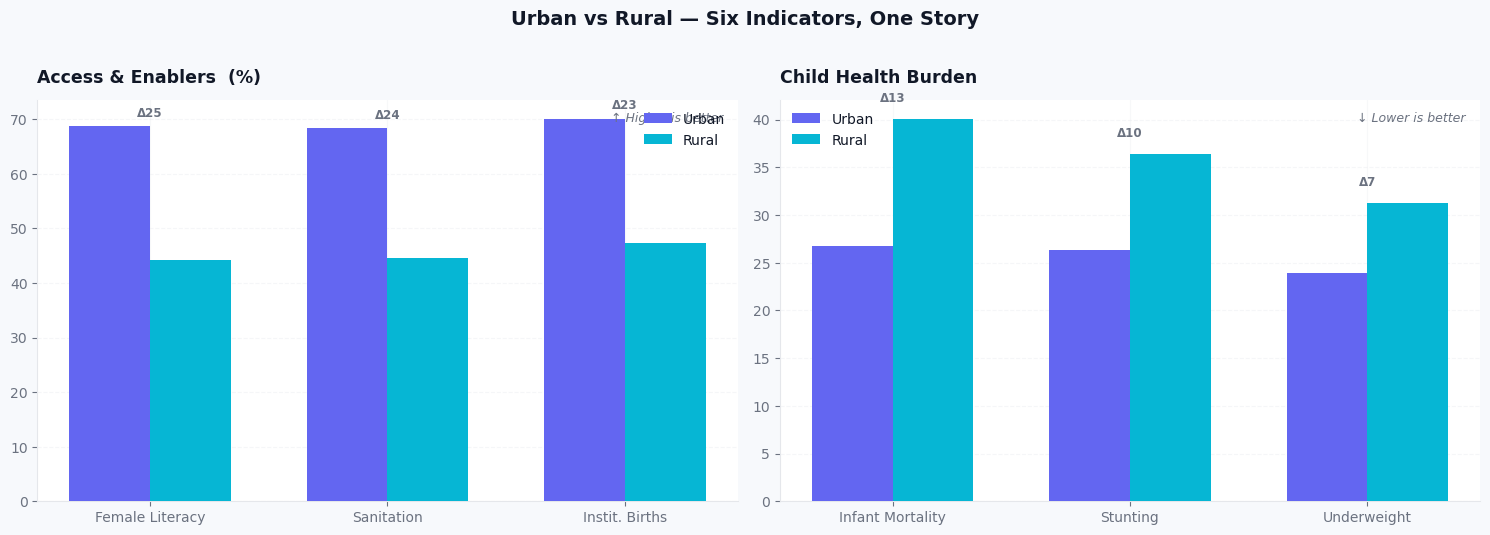

In [31]:
# ══════════════════════════════════════════════════════════════════
# 02 · HERO VISUAL — India's Health Divide
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>02 &middot; THE DIVIDE</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>India's Health Divide</div>
  <div style='font-size:14px;color:#6B7280;margin-top:6px;'>National averages, split by where people live.</div>
</div>
"""))

pos_m = ['female_literacy','sanitation','institutional_births']
neg_m = ['infant_mortality','stunting','underweight']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
fig.patch.set_facecolor(BG_MAIN)

for ax, metrics, title, note in [
    (axes[0], pos_m, 'Access & Enablers  (%)', '\u2191 Higher is better'),
    (axes[1], neg_m, 'Child Health Burden',     '\u2193 Lower is better'),
]:
    u_vals = [df_urban[m].mean() for m in metrics]
    r_vals = [df_rural[m].mean() for m in metrics]
    labs   = [LABELS[m] for m in metrics]
    x = np.arange(len(metrics)); w = 0.34
    ax.bar(x-w/2, u_vals, w, color=PRIMARY,   label='Urban', zorder=3)
    ax.bar(x+w/2, r_vals, w, color=SECONDARY, label='Rural', zorder=3)
    for xi, u, r in zip(x, u_vals, r_vals):
        ax.annotate(f'\u0394{abs(u-r):.0f}', xy=(xi, max(u,r)+1.8),
                    ha='center', fontsize=8.5, color=TEXT_MUTED, fontweight='600')
    ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=10)
    ax.set_title(title, fontsize=12.5, fontweight='700', pad=12, loc='left')
    ax.annotate(note, xy=(0.98,0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color=TEXT_MUTED, style='italic')
    ax.legend(frameon=False, fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.35); ax.set_axisbelow(True)

fig.suptitle('Urban vs Rural \u2014 Six Indicators, One Story',
             fontsize=14, fontweight='800', color=TEXT_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('images/hero_divide.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#EEF2FF;border-radius:12px;
            padding:16px 22px;border-left:4px solid #6366F1;margin:4px 0 28px 0;'>
  <span style='font-weight:700;color:#111827;'>The gap is structural, not small. </span>
  <span style='color:#374151;font-size:13.5px;'>Urban populations outperform rural on every access indicator &mdash;
  and rural areas carry a disproportionate share of child health burden.
  This isn't noise. It's a pattern built over decades.</span>
</div>
"""))

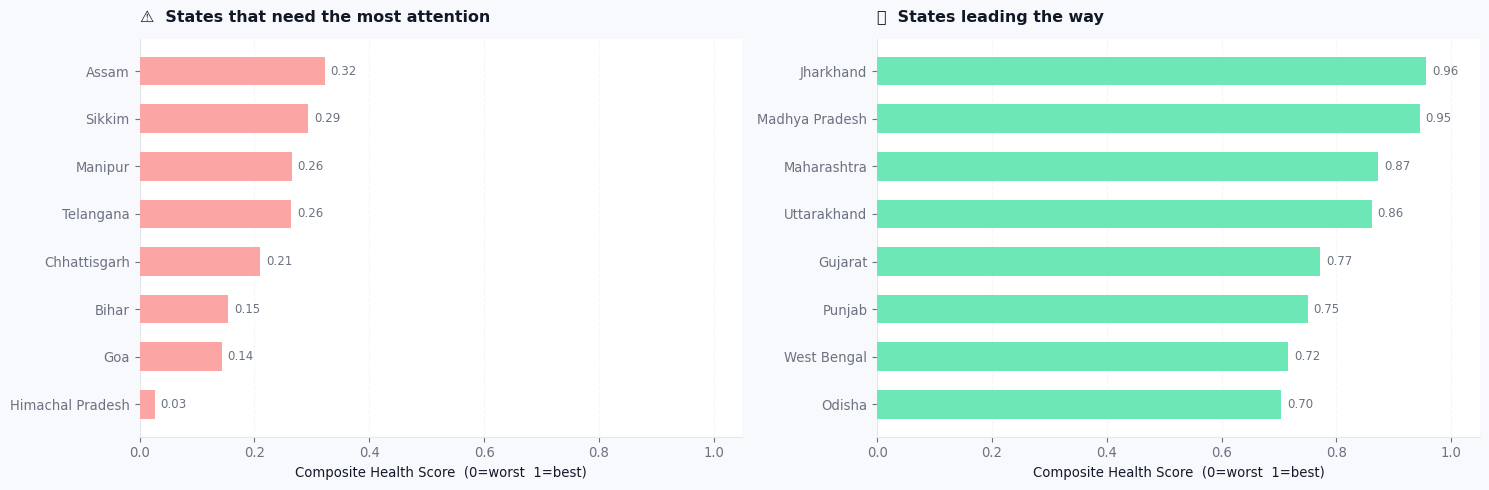

In [21]:
# ══════════════════════════════════════════════════════════════════
# 03 · STATE RANKINGS — Top vs Bottom
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>03 &middot; STATE RANKINGS</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>Two Indias &mdash; side by side</div>
  <div style='font-size:14px;color:#6B7280;margin-top:6px;'>Composite health score built from all six indicators. One number, one ranking.</div>
</div>
"""))

def minmax(s): return (s-s.min())/(s.max()-s.min()+1e-9)
score = pd.Series(0.0, index=df_total.index)
for c in ['female_literacy','sanitation','institutional_births']:
    score += minmax(df_total[c])
for c in ['infant_mortality','stunting','underweight']:
    score += 1 - minmax(df_total[c])
score /= 6

top8    = score.nlargest(8).sort_values()
bottom8 = score.nsmallest(8).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG_MAIN)

for ax, data, color, title in [
    (axes[0], bottom8, '#FCA5A5', '\u26a0\ufe0f  States that need the most attention'),
    (axes[1], top8,   '#6EE7B7', '\u2705  States leading the way'),
]:
    bars = ax.barh(data.index, data.values, color=color, height=0.6, zorder=3)
    ax.set_xlim(0, 1.05)
    ax.set_title(title, fontsize=11.5, fontweight='700', color=TEXT_PRIMARY, pad=12, loc='left')
    ax.tick_params(labelsize=9.5)
    ax.set_xlabel('Composite Health Score  (0=worst  1=best)', fontsize=9.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.35); ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, data.values):
        ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8.5, color=TEXT_MUTED)

plt.tight_layout()
plt.savefig('images/state_ranking.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

best  = score.idxmax()
worst = score.idxmin()
gap_v = score.max()-score.min()

display(HTML(f"""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#FFFFFF;border-radius:12px;
            padding:16px 22px;border-left:4px solid #06B6D4;
            box-shadow:0 2px 10px rgba(0,0,0,0.05);margin:4px 0 28px 0;'>
  <span style='font-weight:700;color:#111827;'>{best} and {worst} are both India &mdash; </span>
  <span style='color:#374151;font-size:13.5px;'>yet their composite scores are {gap_v:.2f} points apart.
  Top performers aren't lucky &mdash; they've built systems. The laggards don't need inspiration, they need investment.</span>
</div>
"""))

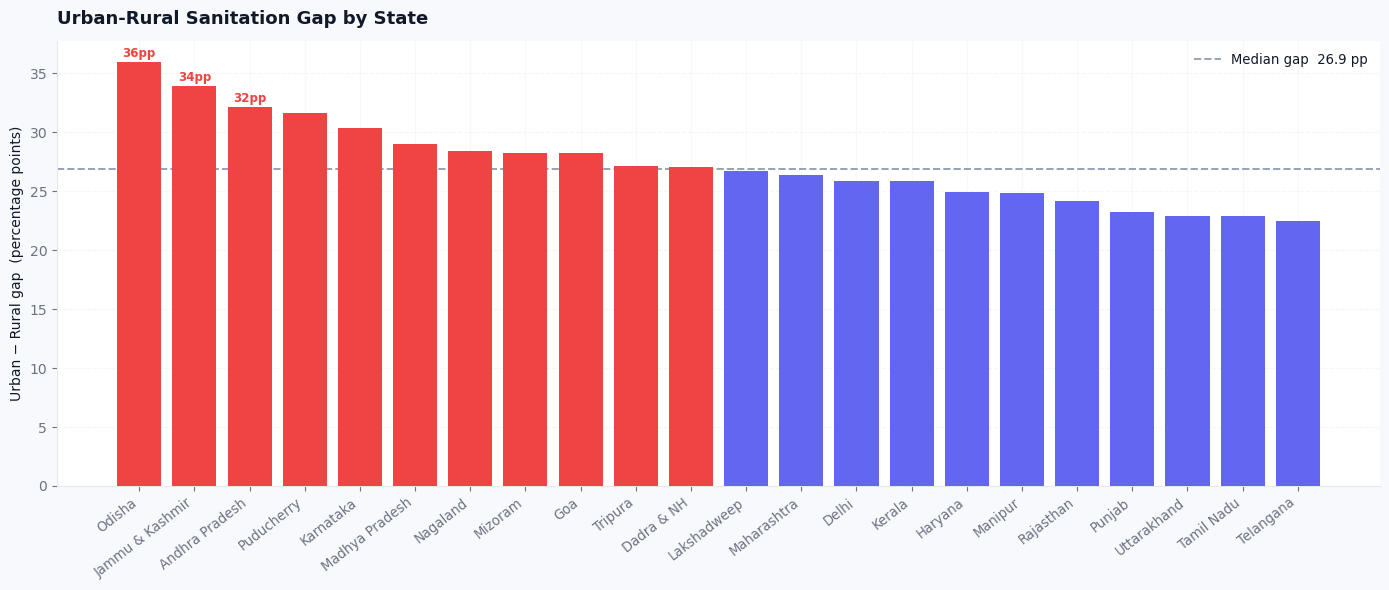

In [32]:
# ══════════════════════════════════════════════════════════════════
# 04 · SANITATION GAP — Per-State Urban-Rural Split
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>04 &middot; SANITATION GAP</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>Sanitation exists. It just doesn't reach the village.</div>
</div>
"""))

common  = df_urban.index.intersection(df_rural.index)
san_gap = (df_urban.loc[common,'sanitation'] - df_rural.loc[common,'sanitation'])
sg_top  = san_gap.sort_values(ascending=False).head(22)
median_g= sg_top.median()

colors = [DANGER if v > median_g else PRIMARY for v in sg_top.values]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_MAIN)
ax.bar(sg_top.index, sg_top.values, color=colors, zorder=3)
ax.axhline(median_g, color='#94A3B8', linestyle='--', linewidth=1.4,
           label=f'Median gap  {median_g:.1f} pp')
ax.set_xticklabels(sg_top.index, rotation=38, ha='right', fontsize=9.5)
ax.set_ylabel('Urban − Rural gap  (percentage points)', fontsize=10)
ax.set_title('Urban-Rural Sanitation Gap by State',
             fontsize=13, fontweight='700', pad=12, loc='left')
ax.legend(frameon=False, fontsize=9.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.35); ax.set_axisbelow(True)
for i, (st, val) in enumerate(sg_top.items()):
    if i < 3:
        ax.text(i, val+0.4, f'{val:.0f}pp', ha='center',
                fontsize=8.5, color=DANGER, fontweight='700')

plt.tight_layout()
plt.savefig('images/sanitation_gap.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

worst_sg = sg_top.idxmax()
worst_v  = sg_top.max()

display(HTML(f"""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#FFFFFF;border-radius:12px;
            padding:16px 22px;border-left:4px solid #EF4444;
            box-shadow:0 2px 10px rgba(0,0,0,0.05);margin:4px 0 28px 0;'>
  <span style='font-weight:700;color:#111827;'>{worst_sg} has a {worst_v:.0f}-point gap &mdash; in a single state. </span>
  <span style='color:#374151;font-size:13.5px;'>Urban residents in the same state are far better served.
  The infrastructure was built &mdash; but it stopped at the city limits.</span>
</div>
"""))

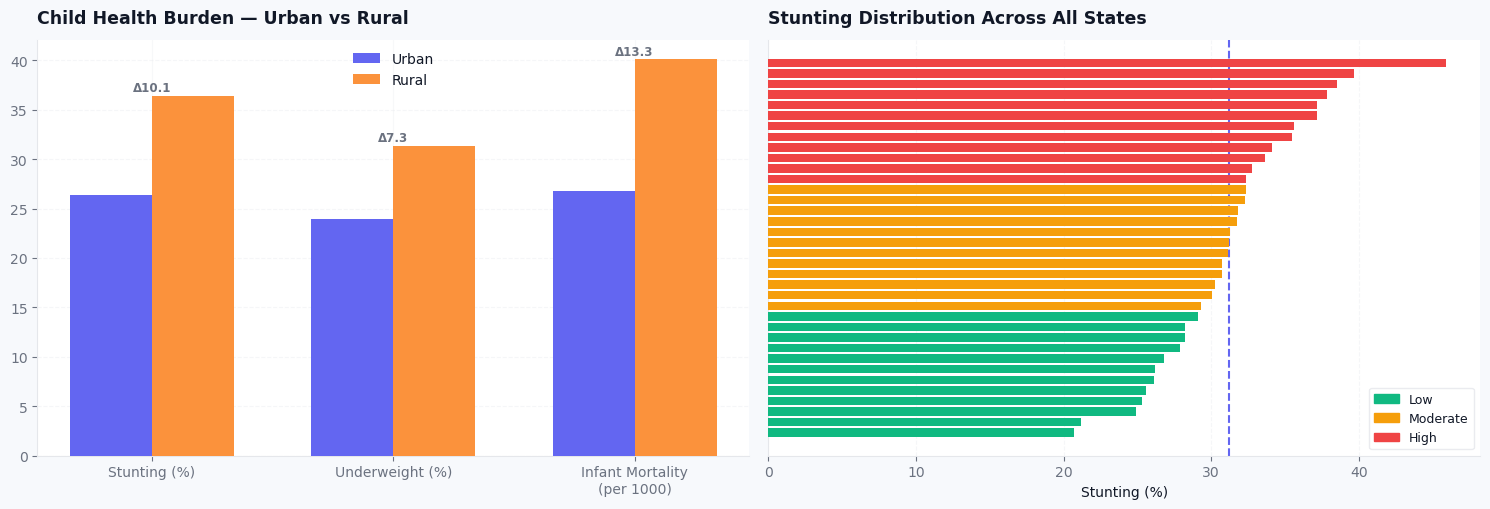

In [23]:
# ══════════════════════════════════════════════════════════════════
# 05 · CHILD HEALTH — Stunting + Mortality
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>05 &middot; CHILD HEALTH</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>Children pay the heaviest price</div>
  <div style='font-size:14px;color:#6B7280;margin-top:6px;'>Stunting and mortality &mdash; the sharpest measures of childhood deprivation.</div>
</div>
"""))

child_m = ['stunting','underweight','infant_mortality']
child_l = ['Stunting (%)','Underweight (%)','Infant Mortality\n(per 1000)']

u_ch = [df_urban[m].mean() for m in child_m]
r_ch = [df_rural[m].mean() for m in child_m]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
fig.patch.set_facecolor(BG_MAIN)

# Left: grouped bar
x = np.arange(len(child_m)); w = 0.34
ax = axes[0]
ax.bar(x-w/2, u_ch, w, color=PRIMARY,   label='Urban', zorder=3)
ax.bar(x+w/2, r_ch, w, color='#FB923C', label='Rural', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(child_l, fontsize=10)
ax.set_title('Child Health Burden \u2014 Urban vs Rural',
             fontsize=12.5, fontweight='700', pad=12, loc='left')
ax.legend(frameon=False, fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.35); ax.set_axisbelow(True)
for xi, u, r in zip(x, u_ch, r_ch):
    ax.annotate(f'\u0394{abs(r-u):.1f}', xy=(xi, max(u,r)+0.5),
                ha='center', fontsize=8.5, color=TEXT_MUTED, fontweight='600')

# Right: stunting state distribution
ax2 = axes[1]
ds = df_total['stunting'].sort_values()
bar_col = [SUCCESS if v < ds.quantile(0.33)
           else WARN if v < ds.quantile(0.66)
           else DANGER for v in ds.values]
ax2.barh(range(len(ds)), ds.values, color=bar_col, height=0.8, zorder=3)
ax2.axvline(ds.mean(), color='#6366F1', linestyle='--', linewidth=1.5)
ax2.set_yticks([])
ax2.set_xlabel('Stunting (%)', fontsize=10)
ax2.set_title('Stunting Distribution Across All States',
              fontsize=12.5, fontweight='700', pad=12, loc='left')
ax2.xaxis.grid(True, linestyle='--', alpha=0.35); ax2.set_axisbelow(True)
patches = [mpatches.Patch(color=SUCCESS,label='Low'),
           mpatches.Patch(color=WARN,   label='Moderate'),
           mpatches.Patch(color=DANGER, label='High')]
ax2.legend(handles=patches, loc='lower right', frameon=True,
           facecolor='white', edgecolor='#E5E7EB', fontsize=9)

plt.tight_layout()
plt.savefig('images/child_health.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

worst_st = df_total['stunting'].idxmax()
best_st  = df_total['stunting'].idxmin()
spread   = df_total['stunting'].max()-df_total['stunting'].min()

display(HTML(f"""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#FFFFFF;border-radius:12px;
            padding:16px 22px;border-left:4px solid #F59E0B;
            box-shadow:0 2px 10px rgba(0,0,0,0.05);margin:4px 0 28px 0;'>
  <span style='font-weight:700;color:#111827;'>A {spread:.0f}-point spread in stunting across Indian states. </span>
  <span style='color:#374151;font-size:13.5px;'>{worst_st} has nearly three times the stunting rate of {best_st}.
  Stunting isn't fate &mdash; it's a direct result of what nutrition, sanitation, and healthcare children receive
  in their first five years. These numbers are preventable.</span>
</div>
"""))

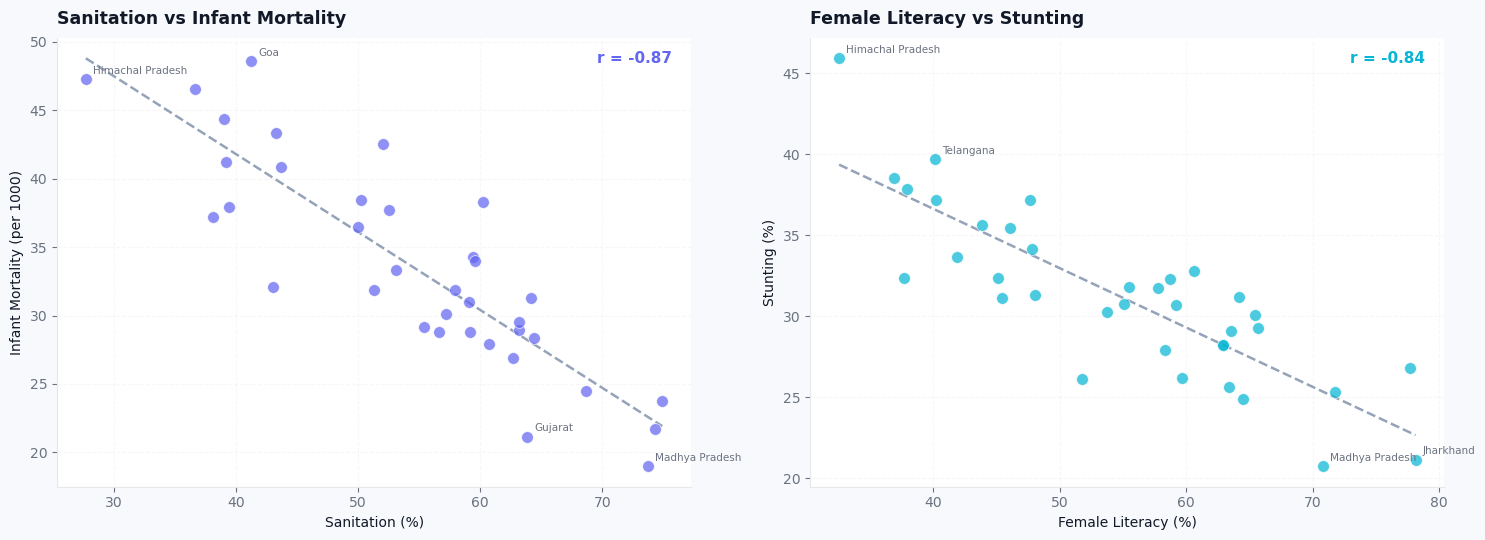

In [24]:
# ══════════════════════════════════════════════════════════════════
# 06 · RELATIONSHIPS — 2 Correlations
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>06 &middot; RELATIONSHIPS</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>Two relationships. Both point the same way.</div>
  <div style='font-size:14px;color:#6B7280;margin-top:6px;'>Toilets and teachers are public health tools.</div>
</div>
"""))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor(BG_MAIN)

pairs = [
    ('sanitation','infant_mortality','Sanitation (%)','Infant Mortality (per 1000)',PRIMARY),
    ('female_literacy','stunting','Female Literacy (%)','Stunting (%)',SECONDARY),
]

for ax, (xc, yc, xl, yl, col) in zip(axes, pairs):
    xd = df_total[xc].values; yd = df_total[yc].values
    ok = ~(np.isnan(xd)|np.isnan(yd))
    ax.scatter(xd[ok], yd[ok], color=col, s=72, alpha=0.72,
               zorder=3, edgecolors='white', linewidth=0.6)
    m, b = np.polyfit(xd[ok], yd[ok], 1)
    xs = np.linspace(xd[ok].min(), xd[ok].max(), 200)
    ax.plot(xs, m*xs+b, color='#94A3B8', linewidth=1.8, linestyle='--', zorder=2)
    r = np.corrcoef(xd[ok], yd[ok])[0,1]
    for st in list(df_total[yc].nlargest(2).index)+list(df_total[yc].nsmallest(2).index):
        if st in df_total.index:
            ax.annotate(st,(df_total.loc[st,xc],df_total.loc[st,yc]),
                        fontsize=7.5,color=TEXT_MUTED,xytext=(5,4),textcoords='offset points')
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.set_title(f'{xl.split("(")[0].strip()} vs {yl.split("(")[0].strip()}',
                 fontsize=12.5, fontweight='700', pad=10, loc='left')
    ax.annotate(f'r = {r:.2f}', xy=(0.97,0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=11, fontweight='700', color=col)
    ax.xaxis.grid(True,linestyle='--',alpha=0.3)
    ax.yaxis.grid(True,linestyle='--',alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('images/correlations.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;background:#FFFFFF;border-radius:12px;
            padding:16px 22px;border-left:4px solid #10B981;
            box-shadow:0 2px 10px rgba(0,0,0,0.05);margin:4px 0 28px 0;'>
  <span style='font-weight:700;color:#111827;'>The pattern is unambiguous. </span>
  <span style='color:#374151;font-size:13.5px;'>States with better sanitation lose fewer infants.
  States with more literate women have less stunting. These aren't coincidences &mdash;
  they're causal pathways that policy already knows how to address.</span>
</div>
"""))

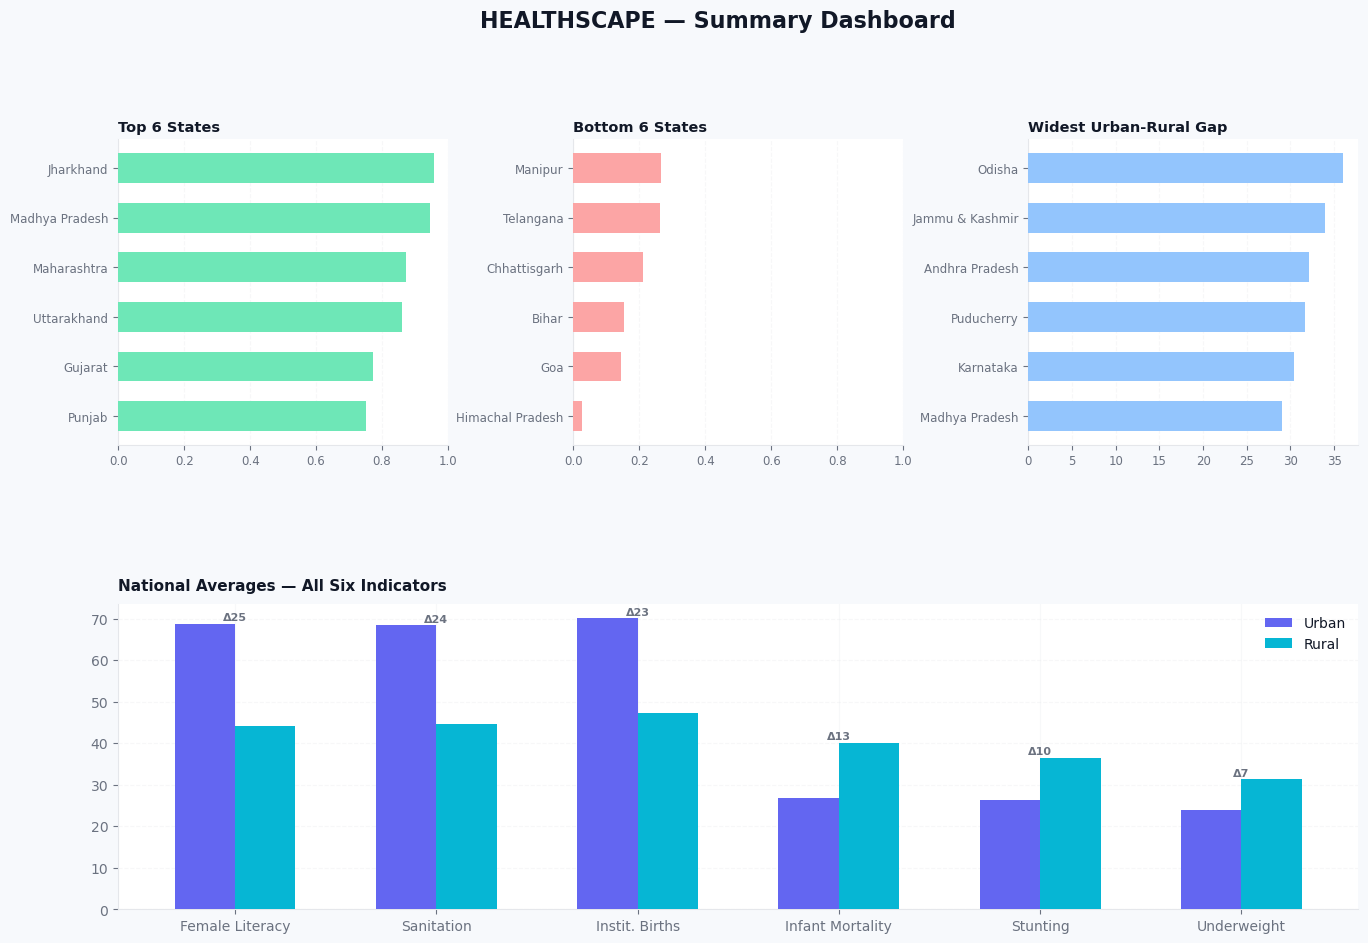

In [25]:
# ══════════════════════════════════════════════════════════════════
# 07 · FINAL DASHBOARD
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 8px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>07 &middot; DASHBOARD</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;'>The full picture &mdash; in one view</div>
</div>
"""))

fig = plt.figure(figsize=(16,10), facecolor=BG_MAIN)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38)

# Top 6
ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor(BG_CARD)
t6 = score.nlargest(6).sort_values()
bars = ax1.barh(t6.index, t6.values, color='#6EE7B7', height=0.6, zorder=3)
ax1.set_title('Top 6 States', fontsize=10.5, fontweight='700', loc='left')
ax1.set_xlim(0,1); ax1.tick_params(labelsize=8.5)
ax1.xaxis.grid(True,linestyle='--',alpha=0.3); ax1.yaxis.grid(False); ax1.set_axisbelow(True)

# Bottom 6
ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor(BG_CARD)
b6 = score.nsmallest(6).sort_values()
ax2.barh(b6.index, b6.values, color='#FCA5A5', height=0.6, zorder=3)
ax2.set_title('Bottom 6 States', fontsize=10.5, fontweight='700', loc='left')
ax2.set_xlim(0,1); ax2.tick_params(labelsize=8.5)
ax2.xaxis.grid(True,linestyle='--',alpha=0.3); ax2.yaxis.grid(False); ax2.set_axisbelow(True)

# Widest gaps
ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor(BG_CARD)
sg6 = san_gap.nlargest(6).sort_values()
ax3.barh(sg6.index, sg6.values, color='#93C5FD', height=0.6, zorder=3)
ax3.set_title('Widest Urban-Rural Gap', fontsize=10.5, fontweight='700', loc='left')
ax3.tick_params(labelsize=8.5)
ax3.xaxis.grid(True,linestyle='--',alpha=0.3); ax3.yaxis.grid(False); ax3.set_axisbelow(True)

# National KPIs
ax4 = fig.add_subplot(gs[1,:]); ax4.set_facecolor(BG_CARD)
kpi_l = [LABELS[c] for c in COLS]
u_kpi = [df_urban[c].mean() for c in COLS]
r_kpi = [df_rural[c].mean() for c in COLS]
x = np.arange(len(COLS)); w = 0.3
ax4.bar(x-w/2, u_kpi, w, color=PRIMARY,   label='Urban', zorder=3)
ax4.bar(x+w/2, r_kpi, w, color=SECONDARY, label='Rural', zorder=3)
ax4.set_xticks(x); ax4.set_xticklabels(kpi_l, fontsize=10)
ax4.set_title('National Averages \u2014 All Six Indicators',
              fontsize=11, fontweight='700', pad=10, loc='left')
ax4.legend(frameon=False, fontsize=10)
ax4.yaxis.grid(True,linestyle='--',alpha=0.3); ax4.set_axisbelow(True)
for xi, u, r in zip(x, u_kpi, r_kpi):
    ax4.text(xi, max(u,r)+0.8, f'\u0394{abs(u-r):.0f}',
             ha='center', fontsize=8, color=TEXT_MUTED, fontweight='600')

fig.suptitle('HEALTHSCAPE \u2014 Summary Dashboard',
             fontsize=16, fontweight='800', color=TEXT_PRIMARY, y=1.01)
plt.savefig('images/dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG_MAIN)
plt.show()

In [26]:
# ══════════════════════════════════════════════════════════════════
# 08 · LIMITATIONS
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;margin:24px 0 20px 0;'>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;color:#6366F1;margin-bottom:8px;'>08 &middot; LIMITATIONS</div>
  <div style='font-size:28px;font-weight:800;color:#111827;letter-spacing:-0.8px;margin-bottom:18px;'>What this can't tell you</div>
  <div style='display:grid;grid-template-columns:repeat(2,1fr);gap:14px;'>
    <div style='background:#FFFFFF;border-radius:14px;padding:20px;box-shadow:0 2px 10px rgba(0,0,0,0.05);border-top:3px solid #F59E0B;'>
      <div style='font-weight:700;color:#111827;font-size:14px;margin-bottom:6px;'>&#128248; One moment in time</div>
      <div style='font-size:13px;color:#6B7280;line-height:1.65;'>NFHS-5 is a cross-sectional survey. It captures a snapshot, not a trend. Whether things are improving or worsening requires longitudinal data.</div>
    </div>
    <div style='background:#FFFFFF;border-radius:14px;padding:20px;box-shadow:0 2px 10px rgba(0,0,0,0.05);border-top:3px solid #EF4444;'>
      <div style='font-weight:700;color:#111827;font-size:14px;margin-bottom:6px;'>&#128205; State = average</div>
      <div style='font-size:13px;color:#6B7280;line-height:1.65;'>Every state is reduced to one number. District-level and block-level variation is invisible here.</div>
    </div>
    <div style='background:#FFFFFF;border-radius:14px;padding:20px;box-shadow:0 2px 10px rgba(0,0,0,0.05);border-top:3px solid #6366F1;'>
      <div style='font-weight:700;color:#111827;font-size:14px;margin-bottom:6px;'>&#128279; Correlation &ne; cause</div>
      <div style='font-size:13px;color:#6B7280;line-height:1.65;'>Associations here are exploratory. Establishing causality requires econometric or experimental work beyond this dataset.</div>
    </div>
    <div style='background:#FFFFFF;border-radius:14px;padding:20px;box-shadow:0 2px 10px rgba(0,0,0,0.05);border-top:3px solid #10B981;'>
      <div style='font-weight:700;color:#111827;font-size:14px;margin-bottom:6px;'>&#9888;&#65039; Self-reported data</div>
      <div style='font-size:13px;color:#6B7280;line-height:1.65;'>Survey responses carry measurement error. Some figures are estimates. Treat exact values as indicative, not ground truth.</div>
    </div>
  </div>
</div>
"""))

In [27]:
# ══════════════════════════════════════════════════════════════════
# 09 · CONCLUSION
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<div style='font-family:Inter,DejaVu Sans,sans-serif;
            background:linear-gradient(135deg,#6366F1 0%,#3B82F6 55%,#06B6D4 100%);
            border-radius:18px;padding:48px 52px;color:white;
            margin:24px 0 16px 0;position:relative;overflow:hidden;'>
  <div style='position:absolute;top:-70px;right:-70px;width:240px;height:240px;
       border-radius:50%;border:36px solid rgba(255,255,255,0.08);'></div>
  <div style='font-size:10px;font-weight:700;letter-spacing:3px;text-transform:uppercase;
              opacity:0.7;margin-bottom:14px;'>09 &middot; CONCLUSION</div>
  <div style='font-size:32px;font-weight:800;letter-spacing:-1px;line-height:1.1;margin-bottom:28px;'>
    Health inequality in India<br>is structural &mdash; and fixable.</div>
  <div style='display:flex;flex-direction:column;gap:14px;max-width:700px;'>
    <div style='display:flex;gap:14px;align-items:flex-start;'>
      <div style='background:rgba(255,255,255,0.18);border-radius:50%;width:36px;height:36px;min-width:36px;
                  display:flex;align-items:center;justify-content:center;font-size:15px;'>&#129531;</div>
      <div style='font-size:15px;opacity:0.92;line-height:1.65;'>
        The gaps documented here &mdash; between states, between rural and urban &mdash; aren't accidents.
        They're the result of decades of unequal investment in clean water, sanitation, education, and accessible hospitals.
      </div>
    </div>
    <div style='display:flex;gap:14px;align-items:flex-start;'>
      <div style='background:rgba(255,255,255,0.18);border-radius:50%;width:36px;height:36px;min-width:36px;
                  display:flex;align-items:center;justify-content:center;font-size:15px;'>&#127758;</div>
      <div style='font-size:15px;opacity:0.92;line-height:1.65;'>
        The best-performing states prove that strong outcomes are achievable in India.
        Their advantage isn't geography &mdash; it's systems. The question is whether that model gets replicated or forgotten.
      </div>
    </div>
    <div style='display:flex;gap:14px;align-items:flex-start;'>
      <div style='background:rgba(255,255,255,0.18);border-radius:50%;width:36px;height:36px;min-width:36px;
                  display:flex;align-items:center;justify-content:center;font-size:15px;'>&#127919;</div>
      <div style='font-size:15px;opacity:0.92;line-height:1.65;'>
        National schemes need state-specific targeting. The states at the bottom don't need general programs &mdash;
        they need focused attention, more resources, and accountability for delivery at the last mile.
      </div>
    </div>
  </div>
  <div style='margin-top:36px;padding-top:24px;border-top:1px solid rgba(255,255,255,0.2);
              font-size:12px;opacity:0.65;letter-spacing:0.5px;'>
    HEALTHSCAPE &nbsp;&middot;&nbsp; Varchasvee Yaduvanshee &nbsp;&middot;&nbsp; NFHS-5 &middot; India &middot; 2019-21
  </div>
</div>
"""))